In [1]:
print("Welcome to Jupyter!")
print("This is fun!")

Welcome to Jupyter!
This is fun!


In [2]:
x=8

In [3]:
print(x)

8


In [4]:
from pathlib import Path

In [5]:
base_dir= Path.cwd()
csv_path = base_dir/"student_grades.csv"

In [6]:
#Import Pandas into our program and give it an alias of pd
import pandas as pd

In [7]:
#load the contents from the csv file into a dataframe
#A dataframe is a 2 dimensional view of the data
grades = pd.read_csv(csv_path)


In [8]:
#display a dataframe
grades

,Name,Class,Grade
0,Alice,Math,88
1,Bob,Math,92
2,Charlie,Science,85
3,Dana,Math,76
4,Eli,Science,90


In [9]:
grades.head()#shows the first 5 rows

,Name,Class,Grade
0,Alice,Math,88
1,Bob,Math,92
2,Charlie,Science,85
3,Dana,Math,76
4,Eli,Science,90


In [10]:
grades.info()#summary info of the dataframe

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    5 non-null      str  
 1   Class   5 non-null      str  
 2   Grade   5 non-null      int64
dtypes: int64(1), str(2)
memory usage: 252.0 bytes


In [11]:
grades.shape# how many rows and columns

(5, 3)

In [12]:
grades.describe()#returns some statistics

,Grade
count,5.00000
mean,86.20000
std,6.26099
min,76.00000
25%,85.00000
50%,88.00000
75%,90.00000
max,92.00000


In [13]:
#Create a dataframe of only the math students
math_students = grades[grades["Class"] == "Math"]
math_students

,Name,Class,Grade
0,Alice,Math,88
1,Bob,Math,92
3,Dana,Math,76


In [14]:
#How many math students are there?
math_students.shape[0]

3

In [15]:
#sort the math records from highest grade to lowest and display
top_math  = math_students.sort_values(by = "Grade", ascending = False)
top_math

,Name,Class,Grade
1,Bob,Math,92
0,Alice,Math,88
3,Dana,Math,76


In [16]:
#Top math student record
#the first record in the dataframe
top_math.iloc[0]

Name      Bob
Class    Math
Grade      92
Name: 1, dtype: object

In [17]:
#Exercise!
#Get the science records and display them
science_students = grades[grades["Class"] == "Science"]
science_students

,Name,Class,Grade
2,Charlie,Science,85
4,Eli,Science,90


In [18]:
#sort the science records from hightest to lowest grade
top_science  = science_students.sort_values(by = "Grade", ascending = False)
top_science

,Name,Class,Grade
4,Eli,Science,90
2,Charlie,Science,85


In [19]:
#Display the the highest grade science record
top_science.iloc[0]

Name         Eli
Class    Science
Grade         90
Name: 4, dtype: object

In [20]:
#OR
science_students.sort_values(by = "Grade", ascending = False).iloc[0]

Name         Eli
Class    Science
Grade         90
Name: 4, dtype: object

In [21]:
#print the record of the third highest grade
top_grades = grades.sort_values(by = "Grade", ascending = False)
top_grades.iloc[2]

Name     Alice
Class     Math
Grade       88
Name: 0, dtype: object

In [22]:
#print rows 2,3,and 4 from top_grades
top_grades[1:4]

,Name,Class,Grade
4,Eli,Science,90
0,Alice,Math,88
2,Charlie,Science,85


In [25]:
#first 3 rows of top_grades
top_grades[:3]

,Name,Class,Grade
1,Bob,Math,92
4,Eli,Science,90
0,Alice,Math,88


In [27]:
#nam of the person with the thrid highest grade
top_grades.iloc[2]["Name"]

'Alice'

In [30]:
#top 3
grades.head(3)

,Name,Class,Grade
0,Alice,Math,88
1,Bob,Math,92
2,Charlie,Science,85


In [31]:
#last 3 rows
grades.tail(3)

,Name,Class,Grade
2,Charlie,Science,85
3,Dana,Math,76
4,Eli,Science,90


In [32]:
#records where grade between 80 and 90:
# & is AND ipandas and jupyter
grades[(grades["Grade"] >=80) & (grades["Grade"] <= 90)]

,Name,Class,Grade
0,Alice,Math,88
2,Charlie,Science,85
4,Eli,Science,90


In [34]:
#what is OR?    |
grades[(grades["Grade"] == 88) | (grades["Grade"] == 85)]


,Name,Class,Grade
0,Alice,Math,88
2,Charlie,Science,85


In [36]:
#average mark for each class
average_grades = grades.groupby("Class")["Grade"].mean()

In [40]:
import matplotlib.pyplot as plt

(array([0, 1]), [Text(0, 0, 'Math'), Text(1, 0, 'Science')])

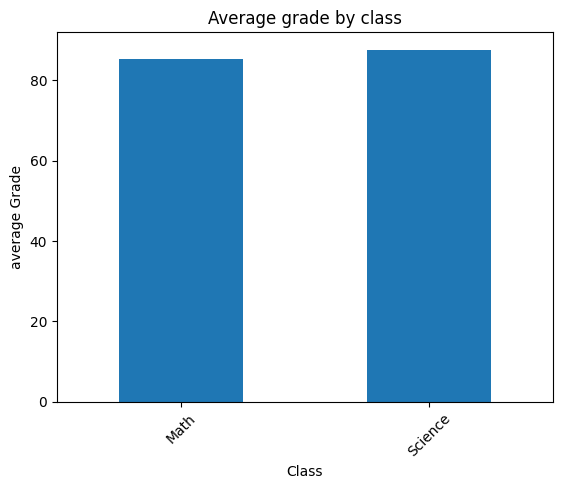

In [42]:
#average mark by class bar chart
average_grades.plot(kind = "bar", title = "Average grade by class")
plt.ylabel("average Grade")
plt.xticks(rotation = 45)


In [43]:
# number of students in each class
grades["Class"].value_counts()

Class
Math       3
Science    2
Name: count, dtype: int64

<Axes: title={'center': 'Students per class'}>

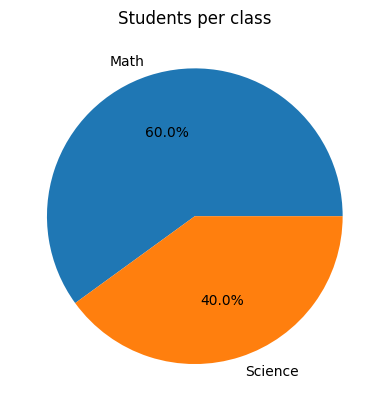

In [46]:
#pie chart of percentage of students in each class
# % → start formatting
# 1.1f →
# 1 = minimum width (not very important here)
# .1 = 1 decimal place
# f = floating point number
# %% → literal % sign (you need two % to show one %)

grades["Class"].value_counts().plot(kind = "pie", autopct ="%1.1F%%" ,title = "Students per class")